# Plot Kimodo Constraints As Skeletons

Notebook para inspecionar cada constraint do jeito que ela entra no Kimodo.

Para `fullbody`, ele reconstrói o `FullBodyConstraintSet` com o esqueleto `SMPLX22` do proprio Kimodo e desenha um esqueleto por keyframe.

In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(suppress=True, precision=4)


In [3]:
PROMPT_ENTRY_PATH = Path(
    "output/robot_emotions_kimodo_generated_single/robot_emotions_10ms_u02_tag11__w000/prompt_entry.json"
)
CONSTRAINTS_PATH = None

MAX_SKELETON_COLUMNS = 4
SKELETON_PANEL_SIZE = 3.8
CENTER_EACH_FRAME_ON_ROOT = False

# Se quiser abrir um constraints.json diretamente, deixe PROMPT_ENTRY_PATH = None
# e ajuste CONSTRAINTS_PATH para o arquivo desejado.


In [4]:
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "kimodo" / "kimodo").exists() and (candidate / "robot_emotions_vlm").exists():
            return candidate
    raise FileNotFoundError("Nao consegui localizar a raiz do repo a partir do cwd atual.")


def import_local_kimodo(repo_root: Path):
    kimodo_repo = repo_root / "kimodo"
    kimodo_repo_str = str(kimodo_repo)
    if kimodo_repo_str not in sys.path:
        sys.path.insert(0, kimodo_repo_str)

    import kimodo  # noqa: F401
    from kimodo.constraints import FullBodyConstraintSet, Root2DConstraintSet
    from kimodo.skeleton import build_skeleton

    return FullBodyConstraintSet, Root2DConstraintSet, build_skeleton


def load_json(path: Path):
    path = Path(path)
    return json.loads(path.read_text(encoding="utf-8"))


def resolve_constraint_bundle(prompt_entry_path=None, constraints_path=None):
    prompt_entry = None
    resolved_constraints_path = None

    if prompt_entry_path is not None:
        prompt_entry = load_json(Path(prompt_entry_path))
        resolved_constraints_path = Path(prompt_entry["constraints_path"])

    if constraints_path is not None:
        resolved_constraints_path = Path(constraints_path)

    if resolved_constraints_path is None:
        raise ValueError("Defina PROMPT_ENTRY_PATH ou CONSTRAINTS_PATH.")

    constraints = load_json(resolved_constraints_path)
    traceability_path = resolved_constraints_path.with_name("traceability.json")
    traceability = load_json(traceability_path) if traceability_path.exists() else None

    return {
        "prompt_entry": prompt_entry,
        "constraints_path": resolved_constraints_path,
        "constraints": constraints,
        "traceability_path": traceability_path if traceability_path.exists() else None,
        "traceability": traceability,
    }


def summarize_bundle(bundle):
    prompt_entry = bundle["prompt_entry"]
    traceability = bundle["traceability"]

    print(f"constraints_path: {bundle['constraints_path']}")
    if bundle["traceability_path"] is not None:
        print(f"traceability_path: {bundle['traceability_path']}")

    if prompt_entry is not None:
        print(f"prompt_id: {prompt_entry['prompt_id']}")
        print(f"reference_clip_id: {prompt_entry['reference_clip_id']}")
        print(f"prompt_text: {prompt_entry['prompt_text']}")

    if traceability is not None:
        print(f"constraint_mode: {traceability['constraint_mode']}")
        print(f"target_fps: {traceability['target_fps']}")
        print(f"constraint_types: {traceability['constraint_types']}")
        print(f"ground_height_m: {traceability['ground_height_m']:.4f}")


REPO_ROOT = find_repo_root()
FullBodyConstraintSet, Root2DConstraintSet, build_skeleton = import_local_kimodo(REPO_ROOT)


/home/henriquesouza/miniconda3/envs/kimodo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def build_smplx22_skeleton():
    return build_skeleton(22)


def source_keyframe_labels(traceability, count: int):
    if traceability is None:
        return [None] * count
    source_keyframes = traceability.get("source_keyframes")
    if source_keyframes is None or len(source_keyframes) != count:
        return [None] * count
    return [int(value) for value in source_keyframes]


def compute_plot_positions(global_joints_positions: np.ndarray, center_on_root: bool) -> np.ndarray:
    positions = np.asarray(global_joints_positions, dtype=np.float32).copy()
    if center_on_root:
        positions -= positions[:, [0], :]
    return positions


def compute_axis_limits(plot_positions: np.ndarray):
    xyz = plot_positions.reshape(-1, 3)
    mins = xyz.min(axis=0)
    maxs = xyz.max(axis=0)
    center = 0.5 * (mins + maxs)
    radius = 0.5 * float(np.max(maxs - mins))
    radius = max(radius, 0.5)
    return center, radius * 1.1


def plot_single_skeleton(ax, joints_xyz, joint_parents, title: str, center, radius):
    joints_xyz = np.asarray(joints_xyz, dtype=np.float32)
    for joint_index, parent_index in enumerate(joint_parents):
        if int(parent_index) < 0:
            continue
        xs = [joints_xyz[int(parent_index), 0], joints_xyz[joint_index, 0]]
        ys = [joints_xyz[int(parent_index), 2], joints_xyz[joint_index, 2]]
        zs = [joints_xyz[int(parent_index), 1], joints_xyz[joint_index, 1]]
        ax.plot(xs, ys, zs, color="tab:blue", linewidth=2)

    ax.scatter(joints_xyz[:, 0], joints_xyz[:, 2], joints_xyz[:, 1], color="black", s=18)
    ax.scatter(joints_xyz[0, 0], joints_xyz[0, 2], joints_xyz[0, 1], color="tab:red", s=40)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x")
    ax.set_ylabel("z")
    ax.set_zlabel("y")
    ax.view_init(elev=18, azim=-72)
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[2] - radius, center[2] + radius)
    ax.set_zlim(center[1] - radius, center[1] + radius)


def plot_fullbody_constraint(constraint, traceability=None, *, constraint_index=0, max_cols=4, panel_size=3.8, center_on_root=False):
    skeleton = build_smplx22_skeleton()
    constraint_set = FullBodyConstraintSet.from_dict(skeleton, constraint)

    frame_indices = np.asarray(constraint["frame_indices"], dtype=np.int32)
    root_positions = np.asarray(constraint["root_positions"], dtype=np.float32)
    smooth_root_2d = np.asarray(constraint.get("smooth_root_2d", root_positions[:, [0, 2]]), dtype=np.float32)
    global_joints_positions = constraint_set.global_joints_positions.detach().cpu().numpy()
    plot_positions = compute_plot_positions(global_joints_positions, center_on_root=center_on_root)
    joint_parents = constraint_set.skeleton.joint_parents.detach().cpu().numpy()
    joint_names = list(constraint_set.skeleton.bone_order_names)
    source_labels = source_keyframe_labels(traceability, len(frame_indices))
    center, radius = compute_axis_limits(plot_positions)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
    axes[0].plot(frame_indices, root_positions[:, 0], marker="o", label="x")
    axes[0].plot(frame_indices, root_positions[:, 1], marker="o", label="y")
    axes[0].plot(frame_indices, root_positions[:, 2], marker="o", label="z")
    axes[0].set_title(f"fullbody[{constraint_index}] root_positions")
    axes[0].set_xlabel("target frame")
    axes[0].set_ylabel("meters")
    axes[0].legend()

    axes[1].plot(smooth_root_2d[:, 0], smooth_root_2d[:, 1], marker="o")
    axes[1].scatter(smooth_root_2d[0, 0], smooth_root_2d[0, 1], label="start", s=60)
    axes[1].scatter(smooth_root_2d[-1, 0], smooth_root_2d[-1, 1], label="end", s=60)
    axes[1].set_title(f"fullbody[{constraint_index}] root trajectory (x,z)")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("z")
    axes[1].axis("equal")
    axes[1].legend()
    plt.show()

    n_frames = len(frame_indices)
    n_cols = min(max_cols, n_frames)
    n_rows = math.ceil(n_frames / n_cols)
    fig = plt.figure(figsize=(panel_size * n_cols, panel_size * n_rows), constrained_layout=True)
    note = "centered on root" if center_on_root else "global positions"
    fig.suptitle(f"fullbody[{constraint_index}] skeleton per keyframe ({note})", fontsize=14)

    for subplot_index in range(n_rows * n_cols):
        ax = fig.add_subplot(n_rows, n_cols, subplot_index + 1, projection="3d")
        if subplot_index >= n_frames:
            ax.set_axis_off()
            continue

        title = f"target {int(frame_indices[subplot_index])}"
        source_label = source_labels[subplot_index]
        if source_label is not None:
            title += f"\nsource {source_label}"

        plot_single_skeleton(
            ax,
            plot_positions[subplot_index],
            joint_parents,
            title,
            center,
            radius,
        )

    plt.show()

    print("joint_names:")
    print(joint_names)


def plot_root2d_constraint(constraint, *, constraint_index=0):
    frames = np.asarray(constraint["frame_indices"], dtype=np.int32)
    root2d = np.asarray(constraint["smooth_root_2d"], dtype=np.float32)
    heading = None if "global_root_heading" not in constraint else np.asarray(constraint["global_root_heading"], dtype=np.float32)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
    axes[0].plot(frames, root2d[:, 0], label="x")
    axes[0].plot(frames, root2d[:, 1], label="z")
    axes[0].set_title(f"root2d[{constraint_index}] coordinates")
    axes[0].set_xlabel("target frame")
    axes[0].set_ylabel("meters")
    axes[0].legend()

    axes[1].plot(root2d[:, 0], root2d[:, 1], marker="o")
    axes[1].scatter(root2d[0, 0], root2d[0, 1], label="start", s=60)
    axes[1].scatter(root2d[-1, 0], root2d[-1, 1], label="end", s=60)
    if heading is not None:
        step = max(1, len(root2d) // 20)
        axes[1].quiver(
            root2d[::step, 0],
            root2d[::step, 1],
            heading[::step, 0],
            heading[::step, 1],
            angles="xy",
            scale_units="xy",
            scale=1.0,
            width=0.004,
            color="tab:red",
        )
    axes[1].set_title(f"root2d[{constraint_index}] trajectory")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("z")
    axes[1].axis("equal")
    axes[1].legend()
    plt.show()


constraints_path: /home/henriquesouza/IMUGPT/output/robot_emotions_kimodo_anchors/robot_emotions_10ms_u02_tag11__w000/constraints.json
traceability_path: /home/henriquesouza/IMUGPT/output/robot_emotions_kimodo_anchors/robot_emotions_10ms_u02_tag11__w000/traceability.json
prompt_id: robot_emotions_10ms_u02_tag11__w000
reference_clip_id: robot_emotions_10ms_u02_tag11
prompt_text: A person stands still, hands clasped together, head slightly tilted, arms moving subtly, legs stationary
constraint_mode: pose3d
target_fps: 30.0
constraint_types: ['fullbody', 'root2d']
ground_height_m: -0.8562

constraint[0] type=fullbody frames=11


/home/henriquesouza/IMUGPT/kimodo/kimodo/skeleton/base.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  neutral_joints = torch.load(pfolder / "joints.p").squeeze()


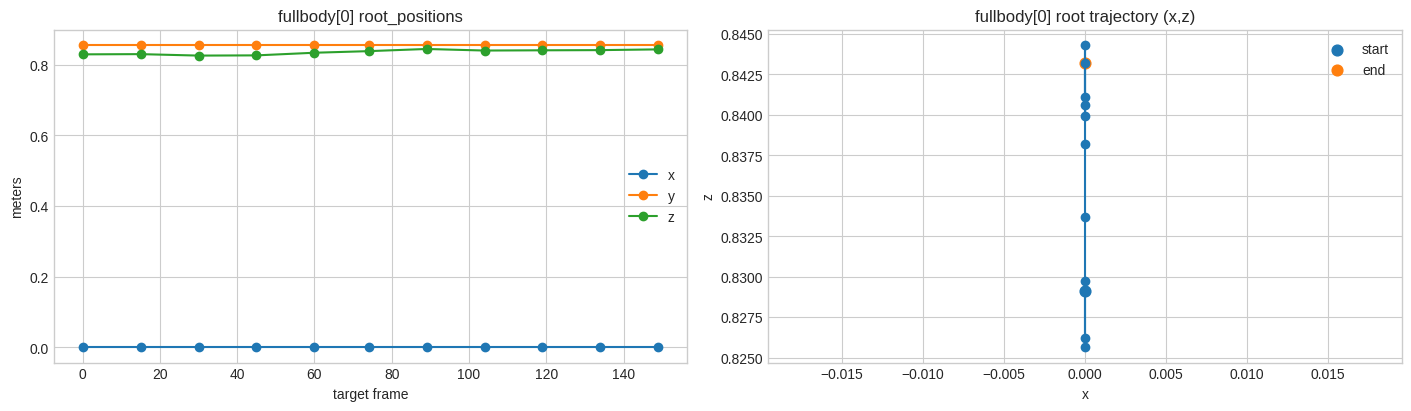

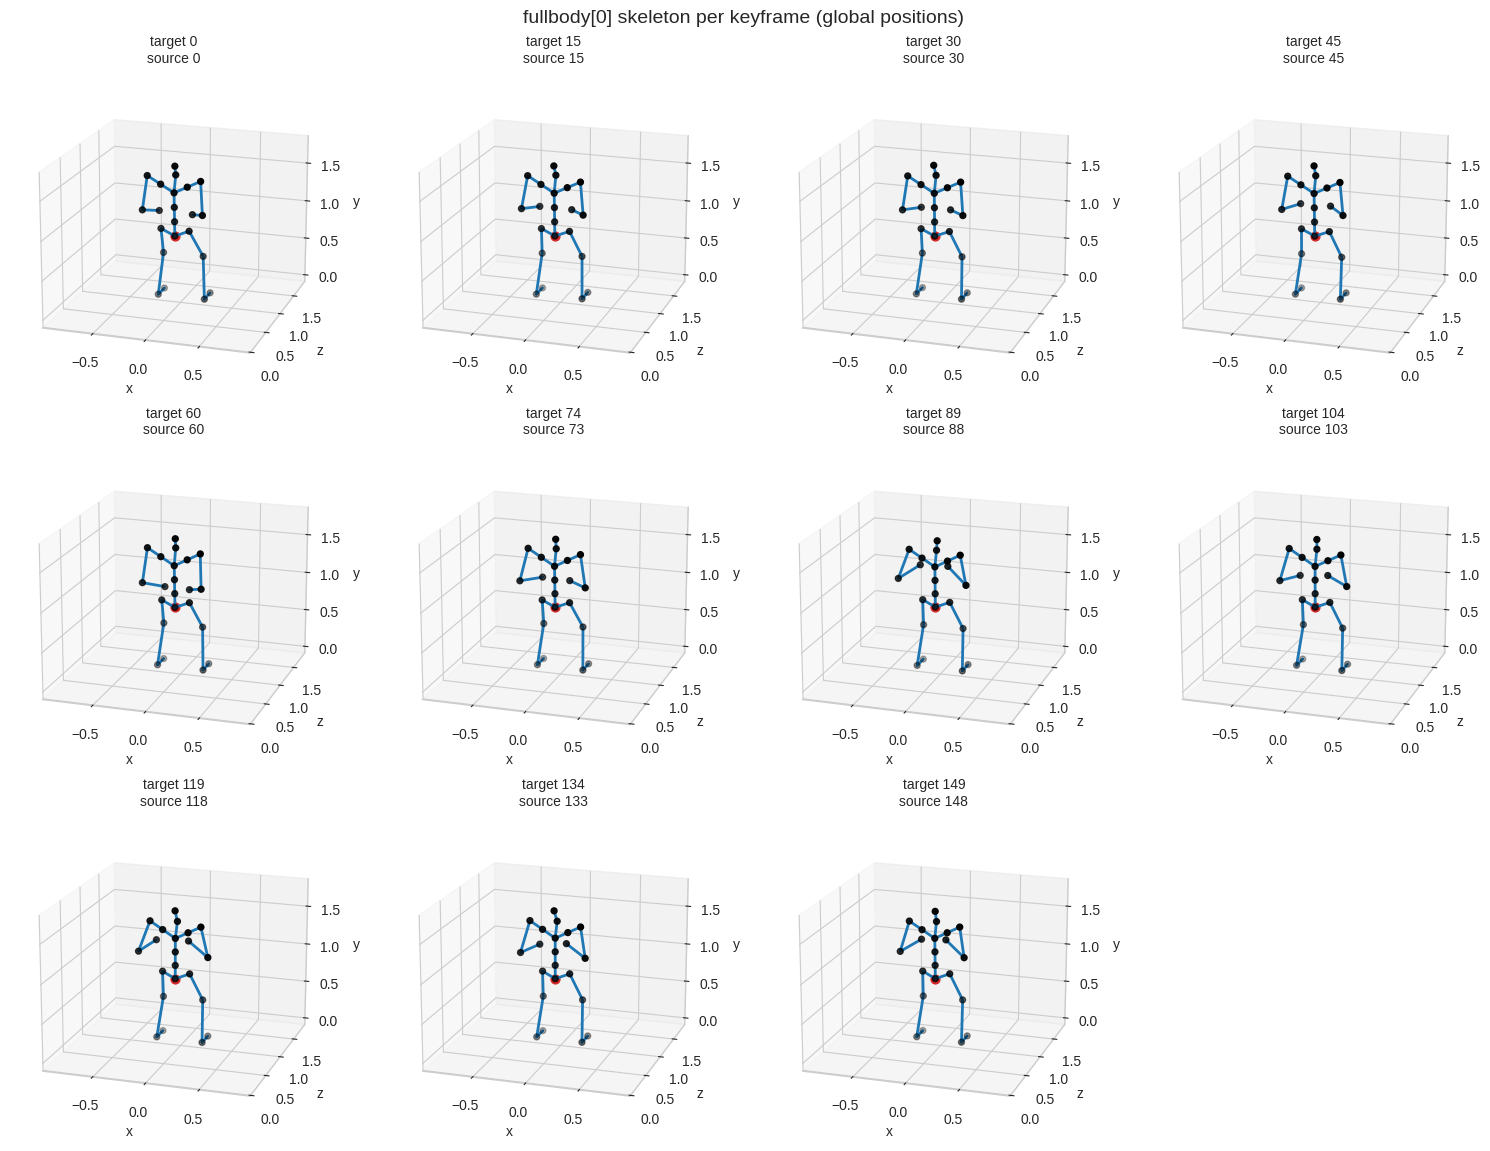

joint_names:
['pelvis', 'left_hip', 'right_hip', 'spine1', 'left_knee', 'right_knee', 'spine2', 'left_ankle', 'right_ankle', 'spine3', 'left_foot', 'right_foot', 'neck', 'left_collar', 'right_collar', 'head', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist', 'right_wrist']

constraint[1] type=root2d frames=150


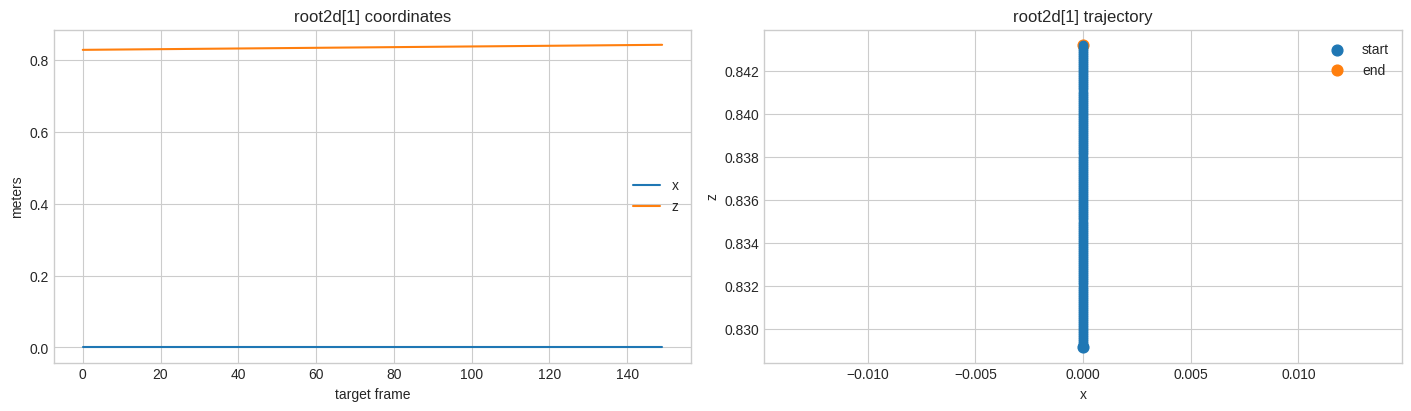

In [6]:
bundle = resolve_constraint_bundle(
    prompt_entry_path=PROMPT_ENTRY_PATH,
    constraints_path=CONSTRAINTS_PATH,
)
summarize_bundle(bundle)

for index, constraint in enumerate(bundle["constraints"]):
    frame_count = len(constraint["frame_indices"])
    print(f"\nconstraint[{index}] type={constraint['type']} frames={frame_count}")
    if constraint["type"] == "fullbody":
        plot_fullbody_constraint(
            constraint,
            bundle["traceability"],
            constraint_index=index,
            max_cols=MAX_SKELETON_COLUMNS,
            panel_size=SKELETON_PANEL_SIZE,
            center_on_root=CENTER_EACH_FRAME_ON_ROOT,
        )
    elif constraint["type"] == "root2d":
        plot_root2d_constraint(constraint, constraint_index=index)
    else:
        print("Tipo ainda nao tratado neste notebook.")
